# Exercise 6 preprocessing

Same idea as exercise 4/5: load the NASA exoplanet data, remove rows with missing values, then log-transform the physical variables.

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


data_file = "PS_2026.05.15_08.06.21.csv"
planets = pd.read_csv(data_file, comment="#")

planets.head()

,loc_rowid,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,1,11 Com b,11 Com,0,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-05-14,2008-01,2014-05-14
1,2,11 Com b,11 Com,1,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-12,2023-09-19
2,3,11 Com b,11 Com,0,2,1,Radial Velocity,2007.0,Xinglong Station,Published Confirmed,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-07-23,2011-08,2014-07-23
3,4,11 UMi b,11 UMi,1,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,Published Confirmed,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-09-04,2017-03,2018-09-06
4,5,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,Published Confirmed,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2009-10,2014-05-14


In [58]:
# Feature columns:
# pl_rade    = planet radius [Earth radii]
# pl_masse   = planet mass [Earth masses]
# pl_dens    = planet density [g/cm^3]
# pl_orbsmax = orbital distance / semi-major axis [au]

feature_columns = ["pl_rade", "pl_masse", "pl_dens", "pl_orbsmax"]

sample_data = planets[feature_columns].apply(pd.to_numeric, errors="coerce")
sample_data = sample_data.dropna()
sample_data = sample_data[(sample_data > 0).all(axis=1)]

# Keep the matching original rows so later prediction features can be added
# without changing the GMM clustering sample.
sample_rows = planets.loc[sample_data.index].reset_index(drop=True).copy()
sample_data = sample_data.reset_index(drop=True)
sample_a = sample_data.to_numpy()

print("number of planets in sample_a:", len(sample_a))


number of planets in sample_a: 2121


In [59]:
# sample_a[:,0] = planet radius
# sample_a[:,1] = planet mass
# sample_a[:,2] = planet density
# sample_a[:,3] = orbital distance

planet_r = sample_a[:, 0].copy()
planet_m = sample_a[:, 1].copy()
planet_density = sample_a[:, 2].copy()
orbital_distance = sample_a[:, 3].copy()

# log10 transformation, same idea as sheet 5
log_planet_r = np.log10(planet_r)
log_planet_m = np.log10(planet_m)
log_planet_density = np.log10(planet_density)
log_orbital_distance = np.log10(orbital_distance)

log_sample_a = np.column_stack((
    log_planet_r,
    log_planet_m,
    log_planet_density,
    log_orbital_distance
))

# Final D-dimensional feature space: D = 4
X = log_sample_a.copy()

print("feature-space dimension D:", X.shape[1])

feature-space dimension D: 4


## Transformation choice

I use a logarithmic transformation for radius, mass, density, and orbital distance because these quantities are positive and span very large ranges. The log transform compresses the scale, reduces skewness, and stops very large planets or very wide orbits from dominating the feature space.

Density is useful because it contains information about composition, but it is correlated with mass and radius.

## Gaussian mixture models

Start by fitting two Gaussian components to each 2D combination of the four log-transformed variables.

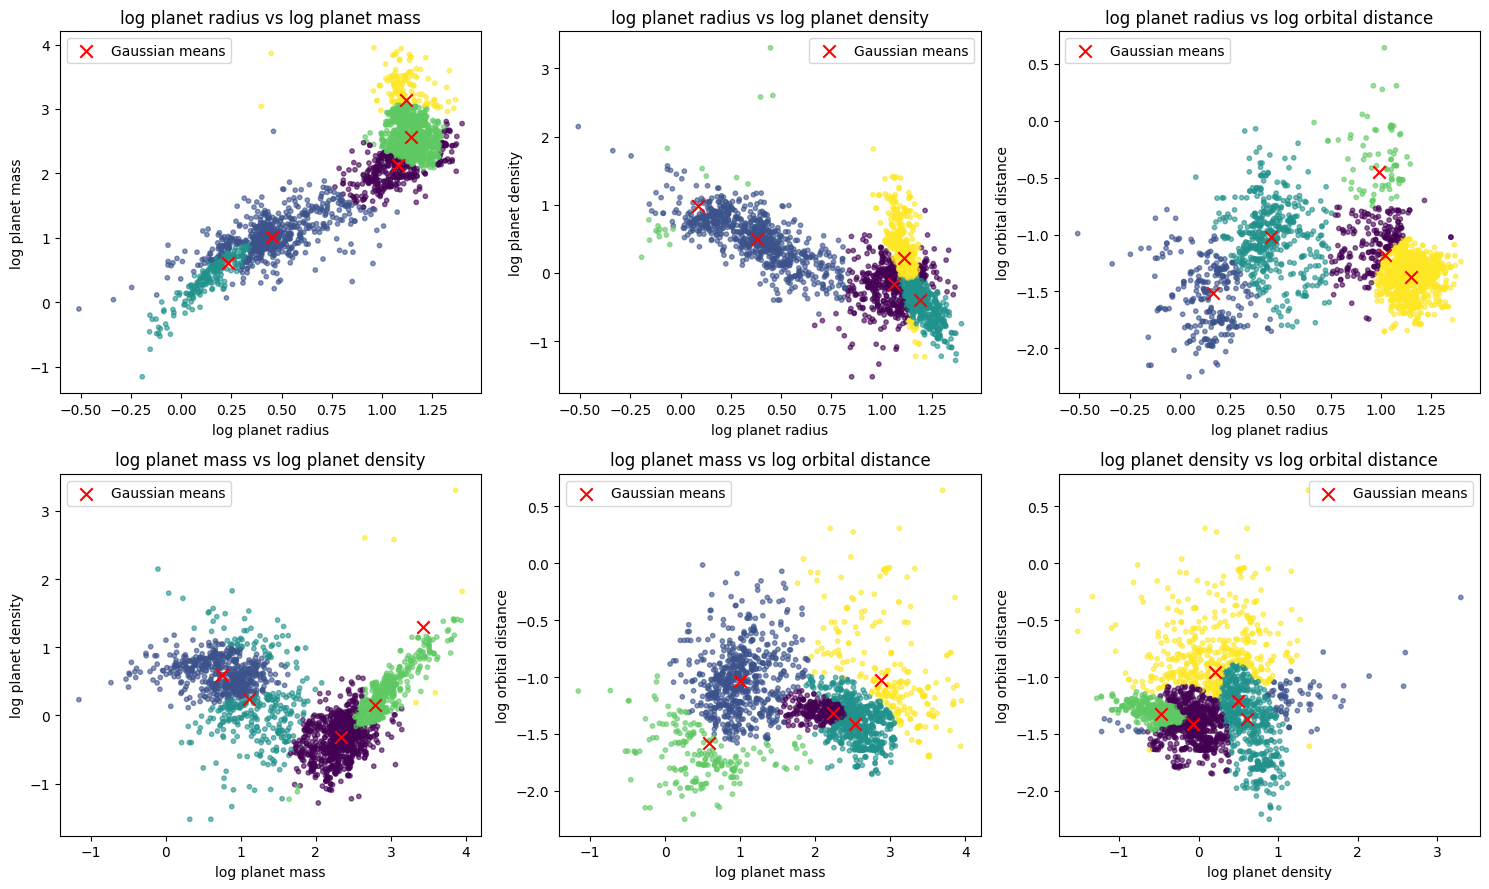

In [60]:
from itertools import combinations
from sklearn.mixture import GaussianMixture


feature_names = [
    "log planet radius",
    "log planet mass",
    "log planet density",
    "log orbital distance"
]

n_components = 5

fig, axs = plt.subplots(2, 3, figsize=(15, 9))
axs = axs.ravel()

for ax, (i, j) in zip(axs, combinations(range(4), 2)):
    X_pair = log_sample_a[:, [i, j]]

    gmm = GaussianMixture(n_components=n_components, random_state=42)
    labels = gmm.fit_predict(X_pair)

    ax.scatter(
        X_pair[:, 0],
        X_pair[:, 1],
        c=labels,
        s=10,
        alpha=0.6
    )

    ax.scatter(
        gmm.means_[:, 0],
        gmm.means_[:, 1],
        c="red",
        marker="x",
        s=80,
        label="Gaussian means"
    )

    ax.set_xlabel(feature_names[i])
    ax.set_ylabel(feature_names[j])
    ax.set_title(f"{feature_names[i]} vs {feature_names[j]}")
    ax.legend()

plt.tight_layout()
plt.show()

In [61]:


feature_spaces = {
    "2D radius-mass": [0, 1],
    "2D radius-density": [0, 2],
    "2D radius-orbit": [0, 3],
    "2D mass-orbit": [2, 3],
    "3D radius-mass-orbit": [0, 1, 3],
    "3D radius-density-orbit": [0, 2, 3],
    "4D all": [0, 1, 2, 3],
}

results = []

for name, cols in feature_spaces.items():
    X_use = log_sample_a[:, cols]

    for k in range(1, 9):
        gmm = GaussianMixture(n_components=k, random_state=42)
        gmm.fit(X_use)

        results.append([name, k, gmm.bic(X_use)])

bic_results = pd.DataFrame(results, columns=["feature_space", "k", "BIC"])



In [62]:
best_bic = bic_results.loc[
    bic_results.groupby("feature_space")["BIC"].idxmin()
]

best_bic


,feature_space,k,BIC
31,2D mass-orbit,8,3933.533477
12,2D radius-density,5,1547.988116
7,2D radius-mass,8,1538.924595
23,2D radius-orbit,8,385.514608
47,3D radius-density-orbit,8,1426.644906
38,3D radius-mass-orbit,7,1363.536812
54,4D all,7,-10641.781125


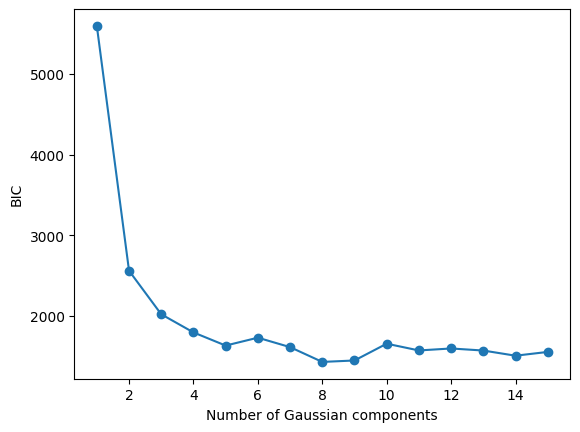

In [63]:
X_3 = log_sample_a[:, [0, 2, 3]]

bic_values = []

for k in range(1, 16):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_3)
    bic_values.append(gmm.bic(X_3))

plt.plot(range(1, 16), bic_values, marker="o")
plt.xlabel("Number of Gaussian components")
plt.ylabel("BIC")
plt.show()


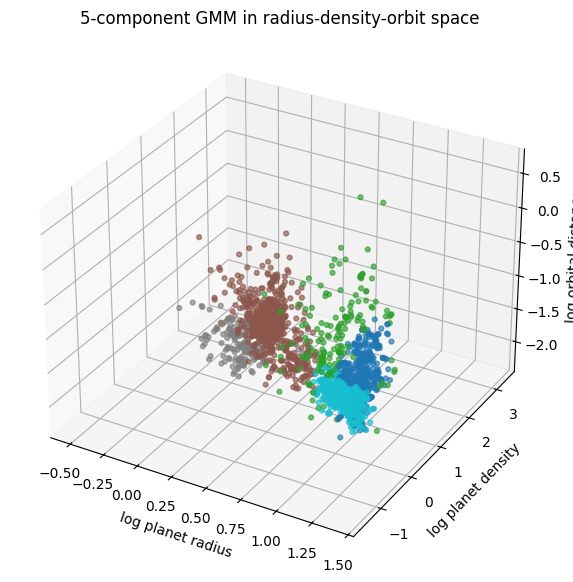

In [64]:

gmm_final = GaussianMixture(
    n_components=5,
    covariance_type="full",
    random_state=42,
    n_init=10
)

labels = gmm_final.fit_predict(X_3)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_3[:, 0],
    X_3[:, 1],
    X_3[:, 2],
    c=labels,
    s=12,
    alpha=0.65,
    cmap="tab10"
)

ax.set_xlabel("log planet radius")
ax.set_ylabel("log planet density")
ax.set_zlabel("log orbital distance")
ax.set_title("5-component GMM in radius-density-orbit space")

plt.show()


In [65]:
centers = pd.DataFrame(
    gmm_final.means_,
    columns=["log radius", "log density", "log orbital distance"]
)


centers_physical = 10**centers
centers_physical.columns = [
    "radius [Earth radii]",
    "density [g/cm^3]",
    "orbital distance [au]"
]

centers_physical


,radius [Earth radii],density [g/cm^3],orbital distance [au]
0,13.479187,1.397814,0.043226
1,10.229568,1.186676,0.144534
2,2.776028,2.582443,0.084182
3,1.361508,5.858651,0.021792
4,14.038579,0.419863,0.044354


In [66]:
log_labeled_data = pd.DataFrame(
    log_sample_a,
    columns=[
        "log_radius",
        "log_mass",
        "log_density",
        "log_orbital_distance"
    ]
)

prediction_extra_columns = [
    "pl_orbper",
    "pl_orbeccen",
    "st_teff",
    "st_rad",
    "st_mass",
    "st_met",
    "st_logg",
    "sy_snum",
    "sy_pnum"
]

prediction_extra_data = sample_rows[prediction_extra_columns].apply(pd.to_numeric, errors="coerce")

# These columns are added only for supervised prediction.
# The GMM labels above are still based on radius, mass, density, and orbital distance.
log_labeled_data["log_orbital_period"] = np.log10(
    prediction_extra_data["pl_orbper"].where(prediction_extra_data["pl_orbper"] > 0)
)
log_labeled_data["orbital_eccentricity"] = prediction_extra_data["pl_orbeccen"]
log_labeled_data["log_stellar_teff"] = np.log10(
    prediction_extra_data["st_teff"].where(prediction_extra_data["st_teff"] > 0)
)
log_labeled_data["log_stellar_radius"] = np.log10(
    prediction_extra_data["st_rad"].where(prediction_extra_data["st_rad"] > 0)
)
log_labeled_data["log_stellar_mass"] = np.log10(
    prediction_extra_data["st_mass"].where(prediction_extra_data["st_mass"] > 0)
)
log_labeled_data["stellar_metallicity"] = prediction_extra_data["st_met"]
log_labeled_data["stellar_logg"] = prediction_extra_data["st_logg"]
log_labeled_data["system_star_count"] = prediction_extra_data["sy_snum"]
log_labeled_data["system_planet_count"] = prediction_extra_data["sy_pnum"]

log_labeled_data["gmm_label"] = labels

log_labeled_data.head()


,log_radius,log_mass,log_density,log_orbital_distance,log_orbital_period,orbital_eccentricity,log_stellar_teff,log_stellar_radius,log_stellar_mass,stellar_metallicity,stellar_logg,system_star_count,system_planet_count,gmm_label
0,0.273001,0.902547,0.823474,-1.811353,-0.132799,0.050,3.713659,-0.025488,-0.043351,0.35,4.43000,2,7,3
1,0.301030,0.936011,0.770852,-1.800519,-0.132804,NaN,NaN,-0.025488,-0.016374,NaN,NaN,2,7,3
2,0.283301,0.907411,0.799341,-1.811353,NaN,NaN,3.720159,-0.016142,-0.045757,0.35,4.42459,2,7,3
3,0.318063,0.892651,0.679428,-1.811353,-0.132801,0.061,3.718834,-0.025488,-0.043351,0.31,4.45000,2,7,3
4,0.281033,0.907411,0.806180,-1.811353,-0.132804,NaN,3.720159,-0.016142,-0.045757,0.35,4.42459,2,7,3


## Supervised models for predicting GMM labels

For the supervised prediction step, planet mass and planet density are removed from the input features. The GMM clusters stay exactly the same, and the prediction models use radius, orbital distance, orbital properties, and stellar/system properties.

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

model_features = [
    "orbital_eccentricity",
    "log_stellar_teff",
    "log_stellar_radius",
    "log_stellar_mass",
    "stellar_metallicity",
    "stellar_logg",
    "system_star_count",
    "system_planet_count"
]
target_column = "gmm_label"

X_model_raw = log_labeled_data[model_features]
y_model = log_labeled_data[target_column]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_model_raw,
    y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

feature_imputer = SimpleImputer(strategy="median")
X_train = pd.DataFrame(
    feature_imputer.fit_transform(X_train_raw),
    columns=model_features,
    index=X_train_raw.index
)
X_test = pd.DataFrame(
    feature_imputer.transform(X_test_raw),
    columns=model_features,
    index=X_test_raw.index
)

missing_by_feature = X_model_raw.isna().sum().sort_values(ascending=False)

print("Training features:", model_features)
print("Removed from model features: log_mass, log_density")
print("Training size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Missing values before median imputation:")
print(missing_by_feature[missing_by_feature > 0])


Training features: ['orbital_eccentricity', 'log_stellar_teff', 'log_stellar_radius', 'log_stellar_mass', 'stellar_metallicity', 'stellar_logg', 'system_star_count', 'system_planet_count']
Removed from model features: log_mass, log_density
Training size: 1696
Test size: 425
Missing values before median imputation:
stellar_logg            485
orbital_eccentricity    345
stellar_metallicity     215
log_stellar_teff         86
log_stellar_mass         43
log_stellar_radius       43
dtype: int64


### Random Forest


In [89]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Random Forest accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))


Random Forest accuracy: 0.5905882352941176
              precision    recall  f1-score   support

           0       0.46      0.56      0.50        97
           1       0.58      0.44      0.50        32
           2       0.69      0.65      0.67       124
           3       0.50      0.31      0.39        35
           4       0.63      0.66      0.65       137

    accuracy                           0.59       425
   macro avg       0.57      0.53      0.54       425
weighted avg       0.60      0.59      0.59       425



### XGBoost


In [90]:
try:
    from xgboost import XGBClassifier

    xgb_model = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    )

    xgb_model.fit(X_train, y_train)
    xgb_pred = xgb_model.predict(X_test)

    print("XGBoost accuracy:", accuracy_score(y_test, xgb_pred))
    print(classification_report(y_test, xgb_pred, zero_division=0))
except ImportError:
    xgb_model = None
    xgb_pred = None
    print("xgboost is not installed. Install it first to run this cell.")


XGBoost accuracy: 0.6023529411764705
              precision    recall  f1-score   support

           0       0.49      0.54      0.51        97
           1       0.64      0.28      0.39        32
           2       0.66      0.72      0.69       124
           3       0.57      0.23      0.33        35
           4       0.62      0.72      0.67       137

    accuracy                           0.60       425
   macro avg       0.60      0.50      0.52       425
weighted avg       0.60      0.60      0.59       425



### CatBoost


In [91]:
try:
    from catboost import CatBoostClassifier

    cat_model = CatBoostClassifier(
        iterations=400,
        depth=5,
        learning_rate=0.05,
        loss_function="MultiClass",
        random_seed=42,
        verbose=False
    )

    cat_model.fit(X_train, y_train)
    cat_pred = cat_model.predict(X_test).ravel()

    print("CatBoost accuracy:", accuracy_score(y_test, cat_pred))
    print(classification_report(y_test, cat_pred, zero_division=0))
except ImportError:
    cat_model = None
    cat_pred = None
    print("catboost is not installed. Install it first to run this cell.")


CatBoost accuracy: 0.56
              precision    recall  f1-score   support

           0       0.45      0.45      0.45        97
           1       0.64      0.22      0.33        32
           2       0.62      0.73      0.67       124
           3       0.67      0.11      0.20        35
           4       0.56      0.68      0.62       137

    accuracy                           0.56       425
   macro avg       0.59      0.44      0.45       425
weighted avg       0.57      0.56      0.54       425



### Neural Network (MLP)


In [92]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

mlp_model = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        random_state=42
    )
)

mlp_model.fit(X_train, y_train)
mlp_pred = mlp_model.predict(X_test)

print("MLP accuracy:", accuracy_score(y_test, mlp_pred))
print(classification_report(y_test, mlp_pred, zero_division=0))


MLP accuracy: 0.5129411764705882
              precision    recall  f1-score   support

           0       0.30      0.18      0.22        97
           1       0.67      0.12      0.21        32
           2       0.62      0.69      0.65       124
           3       0.67      0.11      0.20        35
           4       0.49      0.79      0.61       137

    accuracy                           0.51       425
   macro avg       0.55      0.38      0.38       425
weighted avg       0.51      0.51      0.47       425



### Multiclass Logistic Regression


In [93]:
from sklearn.linear_model import LogisticRegression

logreg_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        solver="lbfgs",
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    )
)

logreg_model.fit(X_train, y_train)
logreg_pred = logreg_model.predict(X_test)

print("Multiclass Logistic Regression accuracy:", accuracy_score(y_test, logreg_pred))
print(classification_report(y_test, logreg_pred, zero_division=0))


Multiclass Logistic Regression accuracy: 0.4588235294117647
              precision    recall  f1-score   support

           0       0.41      0.39      0.40        97
           1       0.24      0.31      0.27        32
           2       0.64      0.39      0.48       124
           3       0.38      0.54      0.45        35
           4       0.48      0.58      0.53       137

    accuracy                           0.46       425
   macro avg       0.43      0.44      0.43       425
weighted avg       0.48      0.46      0.46       425



### Support Vector Machine (SVM)


In [94]:
from sklearn.svm import SVC

svm_model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    )
)

svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("SVM accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred, zero_division=0))


SVM accuracy: 0.48705882352941177
              precision    recall  f1-score   support

           0       0.40      0.51      0.44        97
           1       0.26      0.44      0.33        32
           2       0.67      0.40      0.50       124
           3       0.40      0.46      0.43        35
           4       0.59      0.57      0.58       137

    accuracy                           0.49       425
   macro avg       0.46      0.47      0.46       425
weighted avg       0.53      0.49      0.49       425



### Compare supervised models


In [95]:
model_results = []

model_predictions = {
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "CatBoost": cat_pred,
    "MLP": mlp_pred,
    "Logistic Regression": logreg_pred,
    "SVM": svm_pred
}

for model_name, prediction in model_predictions.items():
    if prediction is None:
        continue

    model_results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, prediction)
    })

results_df = pd.DataFrame(model_results).sort_values("accuracy", ascending=False)
results_df


,model,accuracy
1,XGBoost,0.602353
0,Random Forest,0.590588
2,CatBoost,0.560000
3,MLP,0.512941
5,SVM,0.487059
4,Logistic Regression,0.458824


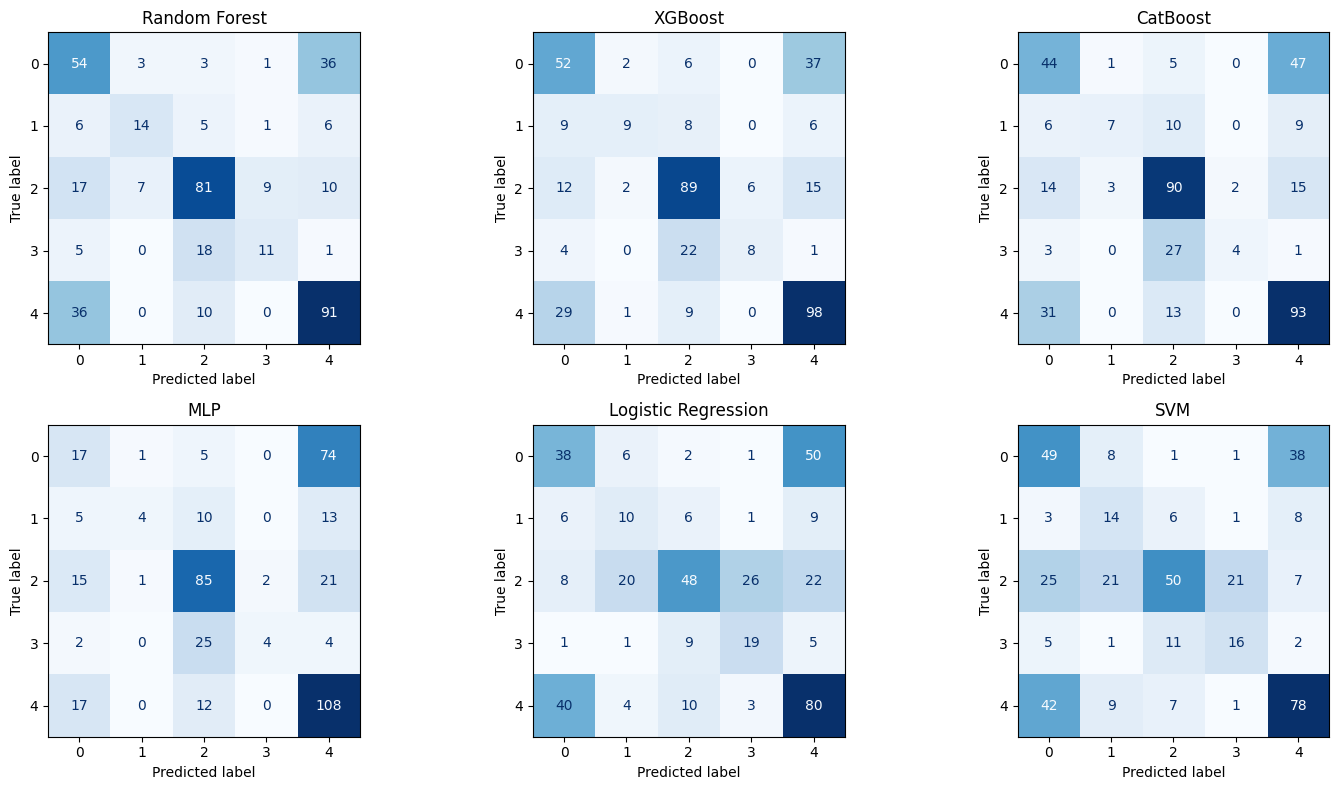

In [96]:
n_models = len(model_predictions)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, (model_name, prediction) in zip(axes, model_predictions.items()):
    ax.set_title(model_name)

    if prediction is None:
        ax.axis("off")
        ax.text(0.5, 0.5, "not installed", ha="center", va="center")
        continue

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        prediction,
        ax=ax,
        cmap="Blues",
        colorbar=False
    )
    ax.set_title(model_name)

for ax in axes[n_models:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


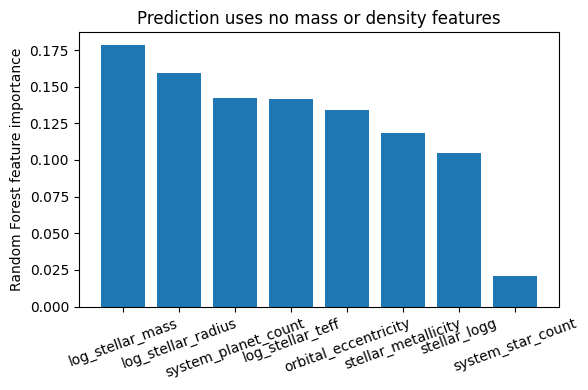

,feature,importance
3,log_stellar_mass,0.178154
2,log_stellar_radius,0.159432
7,system_planet_count,0.142365
1,log_stellar_teff,0.141895
0,orbital_eccentricity,0.133850
4,stellar_metallicity,0.118487
5,stellar_logg,0.104644
6,system_star_count,0.021175


In [97]:
feature_importance = pd.DataFrame({
    "feature": model_features,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(feature_importance["feature"], feature_importance["importance"])
plt.ylabel("Random Forest feature importance")
plt.title("Prediction uses no mass or density features")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

feature_importance
